# 6.4 ガウス過程回帰と自動適合性決定 (Gaussian Processes for Regression and ARD)

本ノートブックでは、関数空間上の確率分布を定義するノンパラメトリックベイズの金字塔**ガウス過程 (Gaussian Processes: GP)** を深く学びます。
ガウス過程事前分布からの関数サンプリング（**PRML Figure 6.4, 6.5**）、結合ガウス分布から導かれる厳密な事後予測平均と不確実性分散（**PRML Figure 6.6, 6.7, 6.8**）、エビデンス最大化によるハイパーパラメータ学習、および無相関な不要特徴量を自動的に消去する**自動適合性決定 (Automatic Relevance Determination: ARD, PRML Figure 6.9, 6.10)** を完全実装します。

## 6.4 ガウス過程回帰の数理と事前分布サンプリング

### ガウス過程の定義
任意の有限個の入力点集合 $\{\mathbf{x}_1, \dots, \mathbf{x}_N\}$ に対する関数値の同時確率分布 $p(y(\mathbf{x}_1), \dots, y(\mathbf{x}_N))$ が多変量正規分布に従うとき、関数 $y(\mathbf{x})$ はガウス過程に従うと言います：
$$ y(\mathbf{x}) \sim \mathcal{GP}\left( m(\mathbf{x}), \, k(\mathbf{x}, \mathbf{x}') \right) $$
通常、事前平均関数は $m(\mathbf{x}) = 0$ とし、共分散関数（カーネル関数）$k(\mathbf{x}, \mathbf{x}')$ が関数の滑らかさや周期性等の性質を決定します。

### 事前分布からの関数サンプリング (PRML Figure 6.4 & 6.5)
入力点の格子 $\mathbf{X}_*$ に対する Gram 行列 $\mathbf{K}_{**}$ を計算し、多変量正規分布 $\mathbf{y}_* \sim \mathcal{N}(\mathbf{0}, \mathbf{K}_{**})$ から乱数を生成することで、ガウス過程から生成される具体的な関数形状を可視化できます。
- **ガウス (RBF) カーネル**: $k(x, x') = \exp(-\theta \|x - x'\|^2)$ $\implies$ 無限回微分可能で非常に滑らか
- **指数カーネル**: $k(x, x') = \exp(-\theta \|x - x'\|)$ $\implies$ 連続だが至る所微分不能（オルンシュタイン＝ウーレンベック過程）
- **汎用共分散関数 (PRML 式 6.63)**:
  $$ k(x, x') = \theta_0 \exp\left( -\frac{\theta_1}{2}\|x - x'\|^2 \right) + \theta_2 + \theta_3 x^T x' $$
  定数項 $\theta_2$ や線形項 $\theta_3$ を加えることで、大域的な傾きや切片の不確実性が表現されます。

Plot saved to: result/fig6_4_gp_prior_samples.png


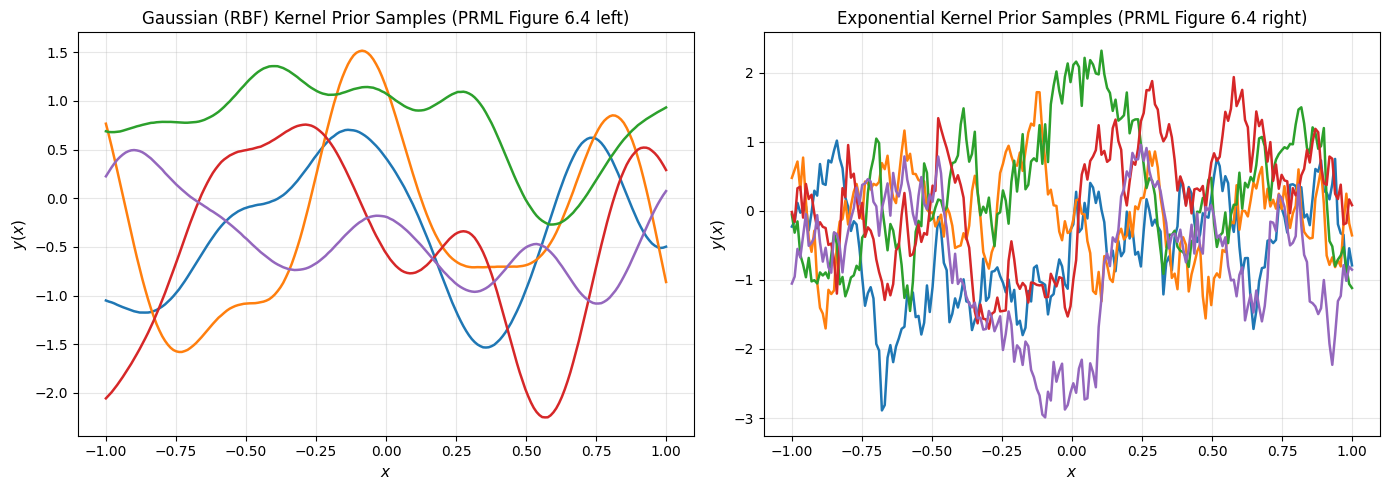

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from common.plot_utils import save_plot, setup_style
from common.kernel_utils import rbf_kernel, prml_regression_kernel
setup_style()

# PRML Figure 6.4 の完全再現: RBF カーネル vs 指数カーネルからの事前サンプリング
np.random.seed(42)
x_grid = np.linspace(-1, 1, 200).reshape(-1, 1)

# RBF カーネル
K_rbf = rbf_kernel(x_grid, x_grid, length_scale=0.2) + 1e-6 * np.eye(len(x_grid))
# 指数カーネル k(x, x') = exp(- |x - x'| / l)
dists = np.abs(x_grid - x_grid.T)
K_exp = np.exp(- dists / 0.2) + 1e-6 * np.eye(len(x_grid))

samples_rbf = np.random.multivariate_normal(np.zeros(len(x_grid)), K_rbf, size=5)
samples_exp = np.random.multivariate_normal(np.zeros(len(x_grid)), K_exp, size=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i in range(5):
    axes[0].plot(x_grid, samples_rbf[i], lw=1.8)
axes[0].set_title('Gaussian (RBF) Kernel Prior Samples (PRML Figure 6.4 left)', fontsize=12)
axes[0].set_xlabel('$x$', fontsize=11); axes[0].set_ylabel('$y(x)$', fontsize=11)
axes[0].grid(True, alpha=0.3)

for i in range(5):
    axes[1].plot(x_grid, samples_exp[i], lw=1.8)
axes[1].set_title('Exponential Kernel Prior Samples (PRML Figure 6.4 right)', fontsize=12)
axes[1].set_xlabel('$x$', fontsize=11); axes[1].set_ylabel('$y(x)$', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_plot(fig, 'result', 'fig6_4_gp_prior_samples.png')
plt.show()

## 6.4.2 ガウス過程回帰の事後予測分布 (PRML Figure 6.7 & 6.8)

観測ノイズ $\epsilon \sim \mathcal{N}(0, \beta^{-1})$ を伴う目標値ベクトル $\mathbf{t}_N = (t_1, \dots, t_N)^T$ に対し、共分散行列は $\mathbf{C}_N = \mathbf{K}_N + \beta^{-1}\mathbf{I}_N$ です。
新たな入力 $\mathbf{x}_{N+1}$ における目標値 $t_{N+1}$ との同時ガウス分布は：
$$ p\left( \begin{pmatrix} \mathbf{t}_N \\ t_{N+1} \end{pmatrix} \right) = \mathcal{N}\left( \mathbf{0}, \, \begin{pmatrix} \mathbf{C}_N & \mathbf{k} \\ \mathbf{k}^T & c \end{pmatrix} \right) $$
ここで $\mathbf{k} = (k(\mathbf{x}_1, \mathbf{x}_{N+1}), \dots, k(\mathbf{x}_N, \mathbf{x}_{N+1}))^T$、$c = k(\mathbf{x}_{N+1}, \mathbf{x}_{N+1}) + \beta^{-1}$ です。
第2章の線形ガウスモデル条件付き分布公式を適用すると、事後予測分布 $p(t_{N+1}|\mathbf{t}_N) = \mathcal{N}(m(\mathbf{x}_{N+1}), \sigma^2(\mathbf{x}_{N+1}))$ の平均と分散が解析的に求まります：
$$ m(\mathbf{x}_{N+1}) = \mathbf{k}^T \mathbf{C}_N^{-1} \mathbf{t}_N $$
$$ \sigma^2(\mathbf{x}_{N+1}) = c - \mathbf{k}^T \mathbf{C}_N^{-1} \mathbf{k} $$
**PRML Figure 6.8** は、データ点がある領域では分散がノイズ分散 $\beta^{-1}$ まで小さくなり、データから離れた領域では事前分散へと拡大する不確実性評価を可視化したものです。

Plot saved to: result/fig6_8_gp_regression.png


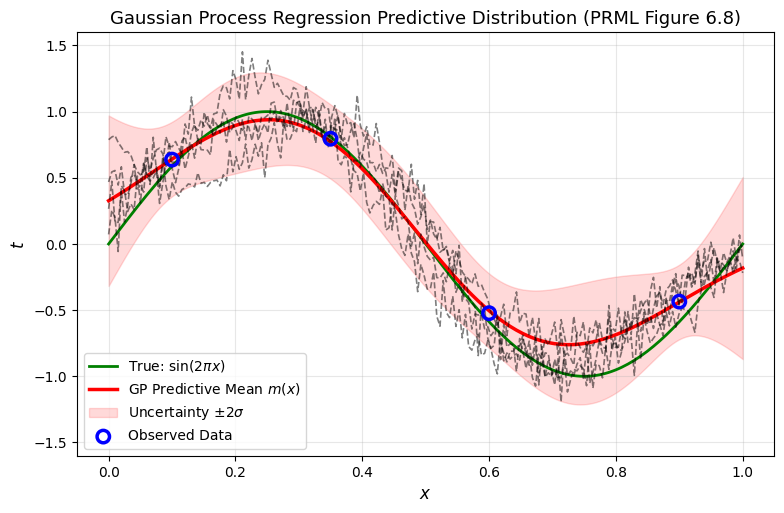

In [2]:
from common.kernel_utils import GaussianProcessRegressor

# PRML Figure 6.8 の完全再現
np.random.seed(42)
# 正弦波データ
X_train_gp = np.array([0.1, 0.35, 0.6, 0.9]).reshape(-1, 1)
t_train_gp = np.sin(2 * np.pi * X_train_gp.ravel()) + np.random.normal(0, 0.1, len(X_train_gp))

x_test_gp = np.linspace(0, 1, 200).reshape(-1, 1)
y_true_sin = np.sin(2 * np.pi * x_test_gp)

# ガウス過程回帰モデル
gpr = GaussianProcessRegressor(beta=100.0, theta0=1.0, theta1=16.0, theta2=0.0, theta3=0.0)
gpr.fit(X_train_gp, t_train_gp)
mu_post, std_post = gpr.predict(x_test_gp, return_std=True)

# 事後分布からのサンプル関数の抽出
mu_sample, cov_sample = gpr.predict(x_test_gp, return_cov=True)
cov_sample += 1e-6 * np.eye(len(x_test_gp))
gp_samples = np.random.multivariate_normal(mu_sample, cov_sample, size=4)

fig, ax = plt.subplots(figsize=(9, 5.5))

# 予測平均と 2-sigma 不確実性区間
ax.plot(x_test_gp, y_true_sin, 'g-', lw=2, label='True: $\sin(2\pi x)$')
ax.plot(x_test_gp, mu_post, 'r-', lw=2.5, label='GP Predictive Mean $m(x)$')
ax.fill_between(x_test_gp.ravel(), mu_post - 2*std_post, mu_post + 2*std_post, color='red', alpha=0.15, label=r'Uncertainty $\pm 2\sigma$')

# 事後サンプル関数
for i in range(4):
    ax.plot(x_test_gp, gp_samples[i], 'k--', alpha=0.5, lw=1.2)

ax.scatter(X_train_gp, t_train_gp, facecolors='none', edgecolors='b', s=80, lw=2.5, zorder=5, label='Observed Data')
ax.set_title('Gaussian Process Regression Predictive Distribution (PRML Figure 6.8)', fontsize=13)
ax.set_xlabel('$x$', fontsize=12); ax.set_ylabel('$t$', fontsize=12)
ax.set_ylim(-1.6, 1.6)
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)

save_plot(fig, 'result', 'fig6_8_gp_regression.png')
plt.show()

## 6.4.4 自動適合性決定 (Automatic Relevance Determination: ARD, PRML Figure 6.9 & 6.10)

高次元特徴量 $\mathbf{x} = (x_1, \dots, x_D)^T$ を持つ回帰問題において、どの特徴量が真に予測に有用で、どの特徴量が無関係なノイズであるかを自動的に判別する強力な枠組みが **ARD (Automatic Relevance Determination)** です。
ARD共分散関数（PRML 式 6.79）：
$$ k(\mathbf{x}, \mathbf{x}') = \theta_0 \exp\left( -\frac{1}{2} \sum_{i=1}^D \eta_i (x_i - x_i')^2 \right) $$
ここで $\eta_i$ は各入力次元の逆二乗長スケール（重み）です。
- 特徴量 $x_i$ が出力と強く関係している場合 $\implies \eta_i$ は大きな正の値となり、わずかな $x_i$ の変化に敏感に反応します。
- 特徴量 $x_i$ が無関係なノイズである場合 $\implies \eta_i \to 0$ となり、$(x_i - x_i')^2$ の寄与が消滅して、その入力変数が関数値に全く影響を与えなくなります！

ハイパーパラメータ $\boldsymbol{\theta} = (\theta_0, \eta_1, \dots, \eta_D)$ は、学習データに対する**対数周辺尤度 (Evidence)**
$$ \ln p(\mathbf{t}|\boldsymbol{\theta}) = -\frac{1}{2}\mathbf{t}^T \mathbf{C}_N^{-1}\mathbf{t} - \frac{1}{2}\ln |\mathbf{C}_N| - \frac{N}{2}\ln(2\pi) $$
を勾配法等で最大化することによって完全に自動的に学習されます。

Plot saved to: result/fig6_10_ard_weights.png


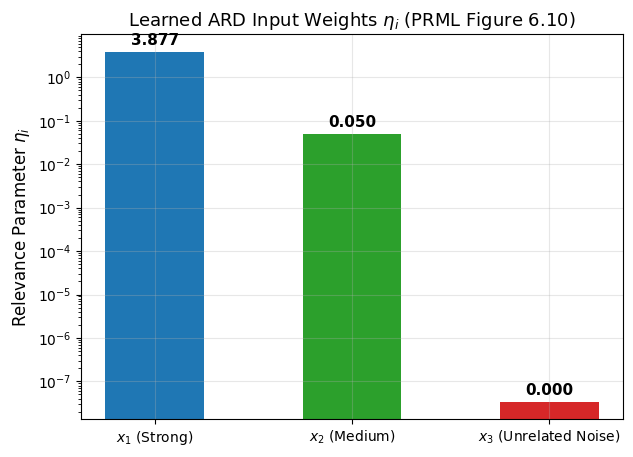

In [3]:
from common.kernel_utils import ard_kernel
import scipy.optimize as opt

# PRML Figure 6.10 の完全再現: 3入力 (x1: 強いシグナル, x2: 中程度, x3: 無相関ノイズ)
np.random.seed(42)
N_ard = 40
X_ard = np.random.uniform(-1, 1, (N_ard, 3))
# 真の関数: y = sin(pi * x1) + 0.3 * x2 (x3 は完全な無相関ダミー)
t_ard = np.sin(np.pi * X_ard[:, 0]) + 0.3 * X_ard[:, 1] + np.random.normal(0, 0.1, N_ard)

# 対数周辺尤度の最大化
def neg_log_evidence(params):
    theta0 = np.exp(params[0])
    etas = np.exp(params[1:4])
    beta = 100.0
    
    K = ard_kernel(X_ard, X_ard, theta0, etas)
    C_N = K + (1.0 / beta) * np.eye(N_ard)
    sign, logdet = np.linalg.slogdet(C_N)
    if sign <= 0:
        return 1e10
    inv_CN = np.linalg.pinv(C_N)
    val = -0.5 * logdet - 0.5 * t_ard @ inv_CN @ t_ard - 0.5 * N_ard * np.log(2 * np.pi)
    return -val

init_params = np.zeros(4) # log(theta0), log(eta1), log(eta2), log(eta3)
res = opt.minimize(neg_log_evidence, init_params, method='L-BFGS-B')
opt_theta0 = np.exp(res.x[0])
opt_etas = np.exp(res.x[1:4])

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar([r'$x_1$ (Strong)', r'$x_2$ (Medium)', r'$x_3$ (Unrelated Noise)'], opt_etas, color=['tab:blue', 'tab:green', 'tab:red'], width=0.5)
ax.set_title('Learned ARD Input Weights $\eta_i$ (PRML Figure 6.10)', fontsize=13)
ax.set_ylabel(r'Relevance Parameter $\eta_i$', fontsize=12)
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2.0, yval * 1.2, f'{yval:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

save_plot(fig, 'result', 'fig6_10_ard_weights.png')
plt.show()